Missing values:
 MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


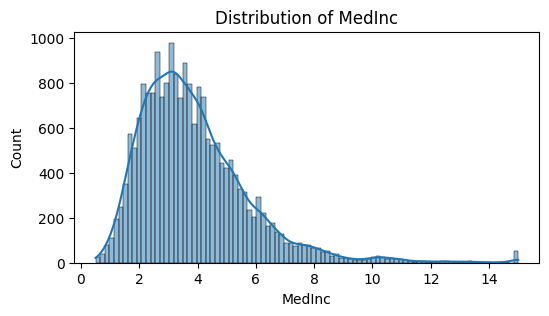

MedInc skewness: 1.65


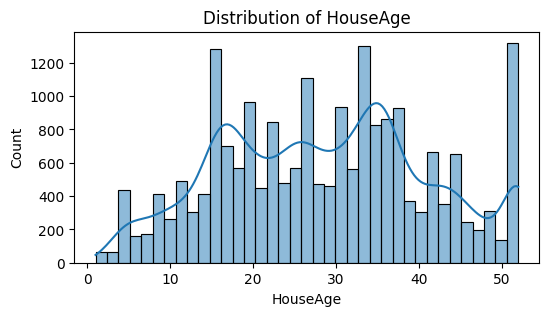

HouseAge skewness: 0.06


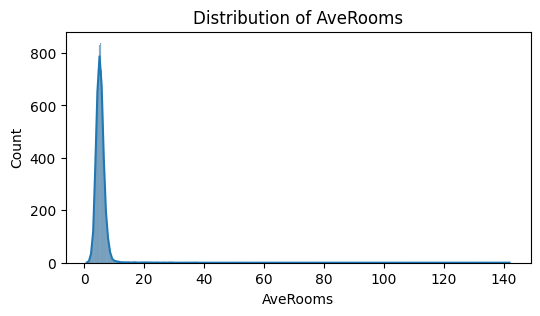

AveRooms skewness: 20.70


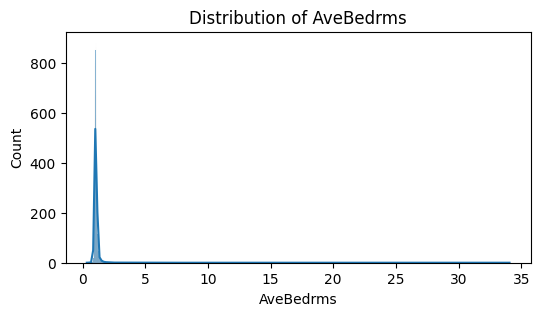

AveBedrms skewness: 31.32


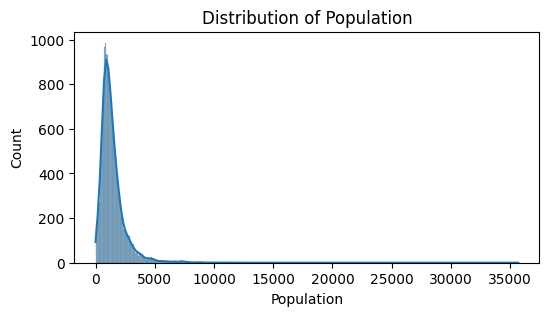

Population skewness: 4.94


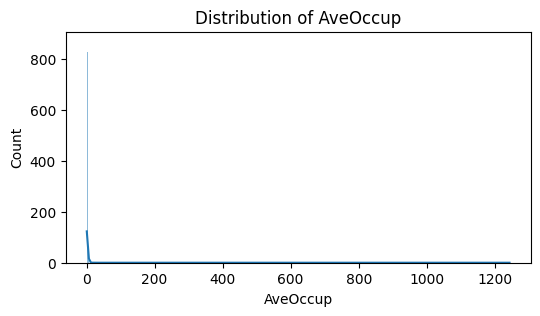

AveOccup skewness: 97.64


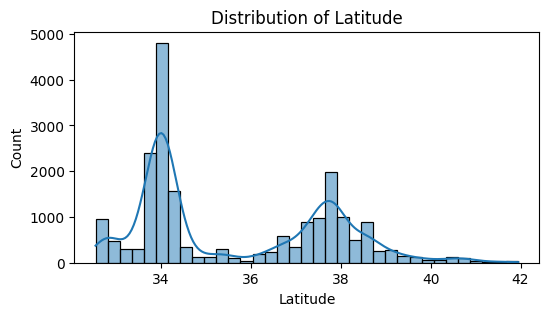

Latitude skewness: 0.47


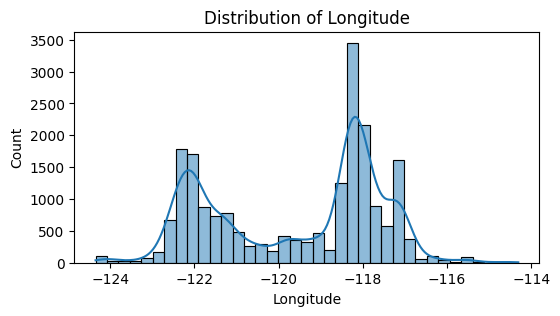

Longitude skewness: -0.30

Regression Model Comparison:
               Model      RMSE       MAE        R2
3           XGBoost  0.471480  0.312041  0.830363
2      RandomForest  0.515707  0.339447  0.797045
1               KNN  0.626769  0.429097  0.700216
0  LinearRegression  0.684378  0.506437  0.642575


In [6]:
# ===============================
# Industry-Style Regression Pipeline
# ===============================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from scipy.special import boxcox1p

# -------------------------------
# 1️⃣ Load California Housing Dataset
# -------------------------------
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing(as_frame=True)
X = data.data
y = data.target

# -------------------------------
# 2️⃣ EDA
# -------------------------------
print("Missing values:\n", X.isnull().sum())

numeric_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object','category']).columns.tolist()

# Numeric distributions + skew
for col in numeric_features:
    plt.figure(figsize=(6,3))
    sns.histplot(X[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()
    skew_val = X[col].skew()
    print(f"{col} skewness: {skew_val:.2f}")

# -------------------------------
# 3️⃣ Train/Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 4️⃣ Preprocessing Pipelines
# -------------------------------
def handle_skew_outliers(X_numeric):
    X_numeric = pd.DataFrame(X_numeric, columns=numeric_features)
    for col in numeric_features:
        # Outlier capping using 1.5*IQR
        Q1 = X_numeric[col].quantile(0.25)
        Q3 = X_numeric[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5*IQR
        upper = Q3 + 1.5*IQR
        X_numeric[col] = np.clip(X_numeric[col], lower, upper)
        
        # Skew correction for |skew|>1
        skew_val = X_numeric[col].skew()
        if skew_val > 1 or skew_val < -1:
            # Box-Cox requires positive values
            X_numeric[col] = boxcox1p(X_numeric[col] - X_numeric[col].min() + 1, 0.15)
    return X_numeric.values

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('skew_outlier', FunctionTransformer(handle_skew_outliers)),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# -------------------------------
# 5️⃣ Regression Models
# -------------------------------
models = {
    "LinearRegression": LinearRegression(),
    "KNN": KNeighborsRegressor(),
    "RandomForest": RandomForestRegressor(),
    "XGBoost": XGBRegressor()
}

# -------------------------------
# 6️⃣ Evaluation Loop
# -------------------------------
results = []

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # Fit model
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

# -------------------------------
# 7️⃣ Summary Table
# -------------------------------
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='R2', ascending=False)
print("\nRegression Model Comparison:\n", results_df)


Metric	Purpose
RMSE -	Measures average prediction error (sensitive to large errors)

MAE -	Average absolute error, robust to outliers

R²	- Proportion of variance explained (higher is better)


Model selection logic:

Prefer highest R² + lowest RMSE/MAE

Also consider interpretability: LinearRegression > Tree-based

KNN may overfit small datasets

In [3]:
#Feature importance visualization → for RandomForest and XGBoost

#Residual plots → check model assumptions and errors

#Prediction vs Actual plots → see how well model predicts across range

#Skew correction visualization → optional but great for explaining preprocessing

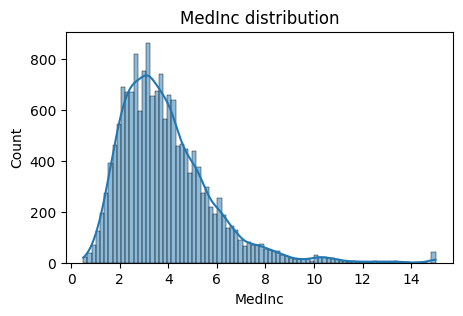

MedInc skewness: 1.63


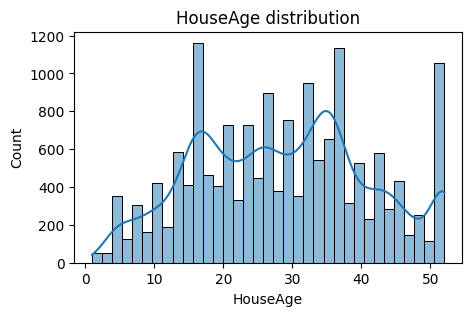

HouseAge skewness: 0.06


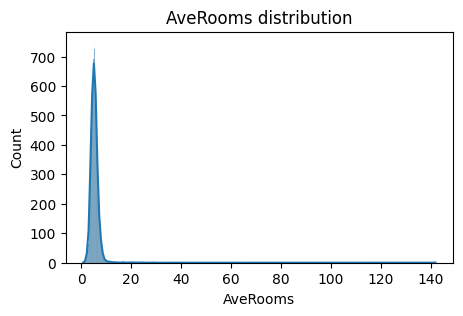

AveRooms skewness: 18.61


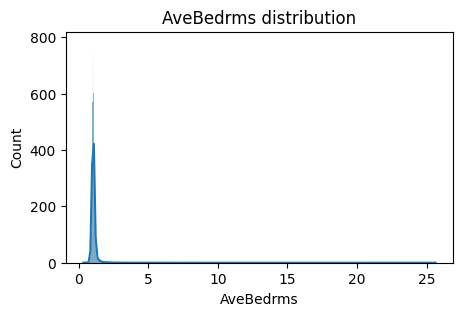

AveBedrms skewness: 23.17


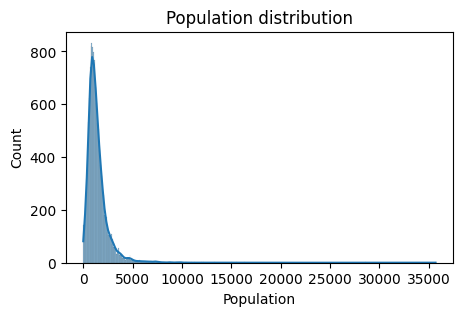

Population skewness: 5.28


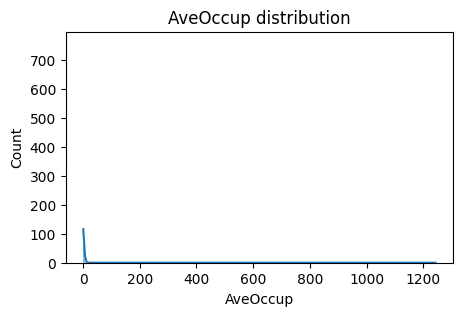

AveOccup skewness: 88.05


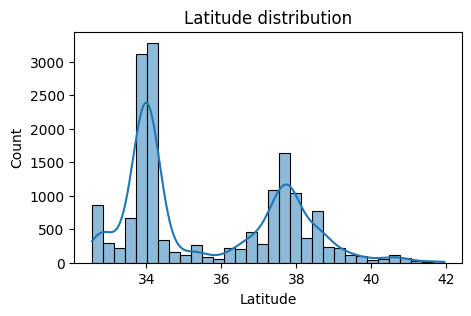

Latitude skewness: 0.46


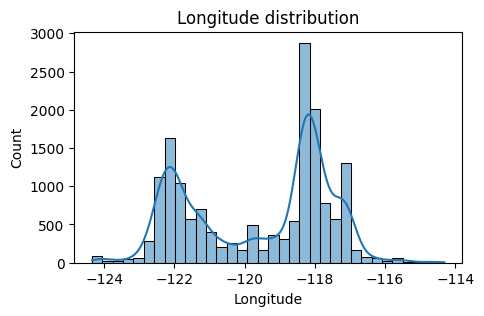

Longitude skewness: -0.29

==== Training LinearRegression ====


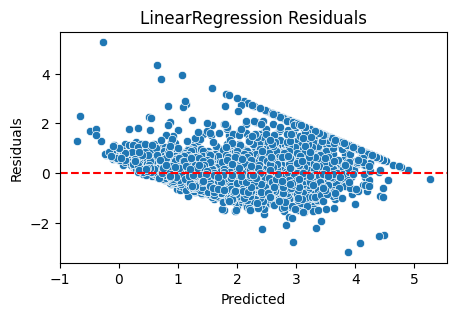

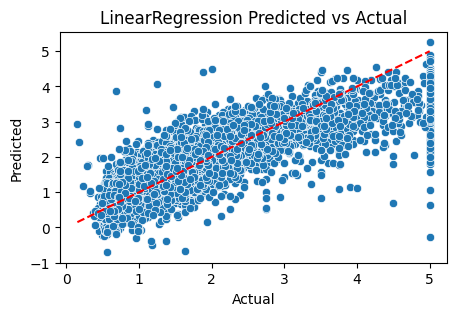


==== Training KNN ====


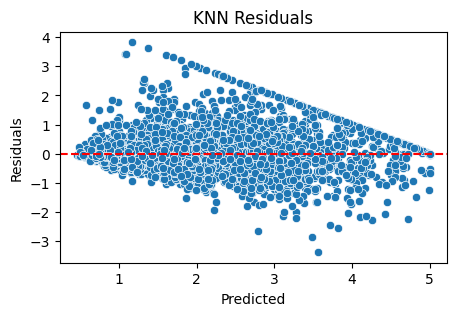

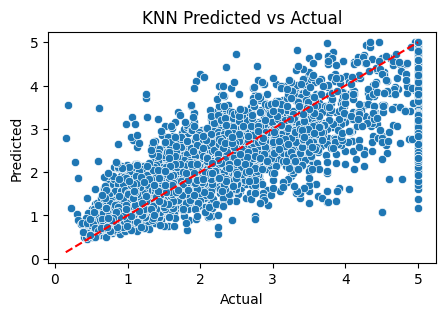


==== Training RandomForest ====


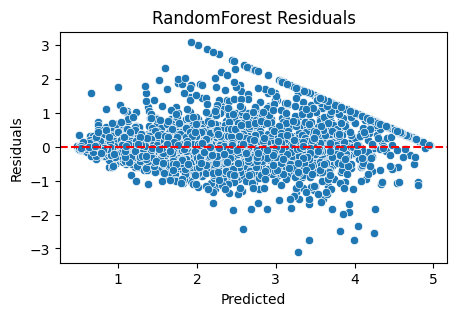

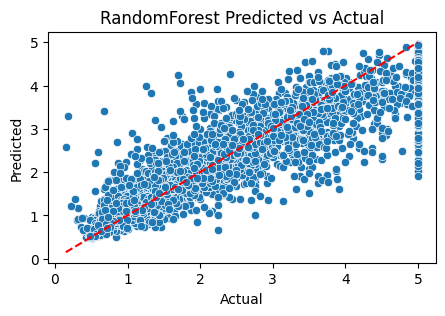

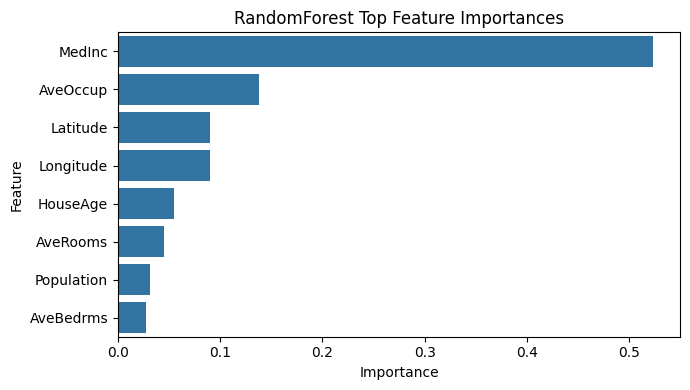


==== Training XGBoost ====


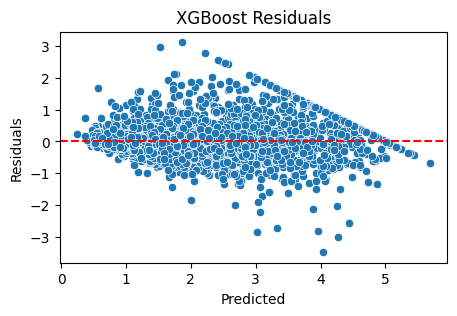

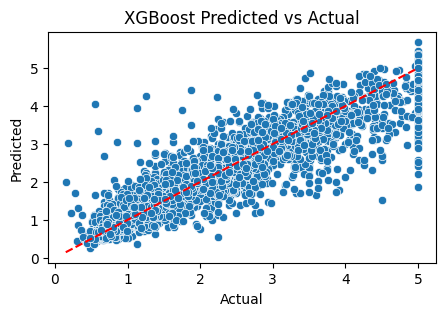

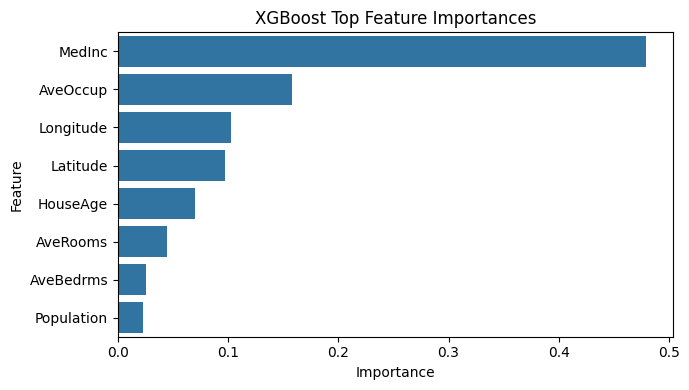


Regression Model Comparison:
               Model      RMSE       MAE        R2
3           XGBoost  0.471480  0.312041  0.830363
2      RandomForest  0.517730  0.340745  0.795450
1               KNN  0.626769  0.429097  0.700216
0  LinearRegression  0.684378  0.506437  0.642575


In [18]:
# ===============================
# Industry-Ready Regression Pipeline (Safe Feature Importance)
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.special import boxcox1p

# -------------------------------
# 1️⃣ Load Dataset
# -------------------------------
data = fetch_california_housing(as_frame=True)
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object','category']).columns.tolist()  # usually empty

# -------------------------------
# 2️⃣ EDA (Optional)
# -------------------------------

for col in numeric_features:
    plt.figure(figsize=(5,3))
    sns.histplot(X_train[col], kde=True)
    plt.title(f"{col} distribution")
    plt.show()
    print(f"{col} skewness: {X_train[col].skew():.2f}")

# -------------------------------
# 3️⃣ Preprocessing Pipelines
# -------------------------------
def handle_skew_outliers(X_numeric):
    X_numeric = pd.DataFrame(X_numeric, columns=numeric_features)
    for col in numeric_features:
        # Outlier capping
        Q1 = X_numeric[col].quantile(0.25)
        Q3 = X_numeric[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5*IQR
        upper = Q3 + 1.5*IQR
        X_numeric[col] = np.clip(X_numeric[col], lower, upper)
        
        # Skew correction
        skew_val = X_numeric[col].skew()
        if skew_val > 1 or skew_val < -1:
            X_numeric[col] = boxcox1p(X_numeric[col] - X_numeric[col].min() + 1, 0.15)
    return X_numeric.values

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('skew_outlier', FunctionTransformer(handle_skew_outliers)),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # sparse_output defaults to True
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# -------------------------------
# 4️⃣ Regression Models
# -------------------------------
models = {
    "LinearRegression": LinearRegression(),
    "KNN": KNeighborsRegressor(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42)
}

# -------------------------------
# 5️⃣ Evaluation & Visualization
# -------------------------------
results = []

for name, model in models.items():
    print(f"\n==== Training {name} ====")
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # Fit pipeline
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })
    
    # Residual plot
    plt.figure(figsize=(5,3))
    sns.scatterplot(x=y_pred, y=y_test - y_pred)
    plt.axhline(0, color='r', linestyle='--')
    plt.xlabel("Predicted")
    plt.ylabel("Residuals")
    plt.title(f"{name} Residuals")
    plt.show()
    
    # Predicted vs Actual
    plt.figure(figsize=(5,3))
    sns.scatterplot(x=y_test, y=y_pred)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{name} Predicted vs Actual")
    plt.show()
    
    # -------------------------------
    # Feature importance for tree models
    # -------------------------------
    if name in ['RandomForest', 'XGBoost']:
        num_features_list = numeric_features
        cat_features_list = []
        if categorical_features:
            ohe = pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
            cat_features_list = ohe.get_feature_names_out(categorical_features)
        all_features = list(num_features_list) + list(cat_features_list)
        
        importances = pipeline.named_steps['regressor'].feature_importances_
        
        fi_df = pd.DataFrame({
            'Feature': all_features,
            'Importance': importances
        }).sort_values(by='Importance', ascending=False).head(15)
        
        plt.figure(figsize=(7,4))
        sns.barplot(data=fi_df, x='Importance', y='Feature')
        plt.title(f"{name} Top Feature Importances")
        plt.tight_layout()
        plt.show()

# -------------------------------
# 6️⃣ Summary Table
# -------------------------------
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='R2', ascending=False)
print("\nRegression Model Comparison:\n", results_df)
